# Homework 1

## FINM 35700 - Spring 2026

### UChicago Financial Mathematics

* Alex Popovici
* alex.popovici@uchicago.edu

This homework relies on:

- the government and corporate bonds symbology file `bond_symbology`, 
- the "on-the-run" treasuries data file `govt_on_the_run` and
- the market data file `market_prices_eod`.


You can find more details on US treasury instruments in the FINM 37400 Fixed Income course.



In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import re

------------------------------------------------------------------------------------------
# Problem 1: Explore symbology for US treasury bonds

## a. Load and explore US government bond symbology

Load the `bond_symbology` Excel file into a dataframe. It contains symbology for both government and corporate bonds as of 2026-03-23.

Select US Treasury bonds only (class = 'Govt', ticker = 'T'). For each government bond issue, calculate its initial `term` in years (based on issue date and maturity date), as well as the current `TTM` (time-to-maturity) and extend the dataframe. Assume a year has 365.25 days.


In [3]:
bond_symbology_df = pd.read_excel('data/bond_symbology.xlsx')
bond_symbology_df.head()

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status
0,AAPL,Corp,BBG004HST0K7,US037833AL42,US912810UT33,AAPL 3.85 05/04/43,APPLE INC,GLOBAL,3.850,FIXED,...,2013-05-03,2013-11-04,2013-05-03,2043-05-04,AT MATURITY,Sr Unsecured,3000.0,US,USD,ACTV
1,AAPL,Corp,BBG006F8VWJ7,US037833AT77,US912810UT33,AAPL 4.45 05/06/44,APPLE INC,GLOBAL,4.450,FIXED,...,2014-05-06,2014-11-06,2014-05-06,2044-05-06,AT MATURITY,Sr Unsecured,1000.0,US,USD,ACTV
2,AAPL,Corp,BBG0081TNL50,US037833BA77,US912810UT33,AAPL 3.45 02/09/45,APPLE INC,GLOBAL,3.450,FIXED,...,2015-02-09,2015-08-09,2015-02-09,2045-02-09,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV
3,AAPL,Corp,BBG008N1BQC1,US037833BH21,US912810UT33,AAPL 4 3/8 05/13/45,APPLE INC,GLOBAL,4.375,FIXED,...,2015-05-13,2015-11-13,2015-05-13,2045-05-13,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV
4,AAPL,Corp,BBG00C7QBCQ1,US037833BW97,US91282CPZ85,AAPL 4 1/2 02/23/36,APPLE INC,GLOBAL,4.500,FIXED,...,2016-02-23,2016-08-23,2016-02-23,2036-02-23,CALLABLE,Sr Unsecured,1250.0,US,USD,ACTV


In [5]:
bond_symbology_df = bond_symbology_df[(bond_symbology_df['class'] == 'Govt') & (bond_symbology_df['ticker'] == 'T')]
bond_symbology_df.head()

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status
893,T,Govt,BBG000DKHP42,US912810EG95,US9127963M90,T 8 3/4 08/15/20,US TREASURY N/B,US GOVERNMENT,8.750,FIXED,...,1990-08-15,1991-02-15,1990-08-15,2020-08-15,NORMAL,Unsecured,17059.0,US,USD,INAC
894,T,Govt,BBG000DJN4B7,US912810EH78,NaN,T 7 7/8 02/15/21,US TREASURY N/B,US GOVERNMENT,7.875,FIXED,...,1991-02-15,1991-08-15,1991-02-15,2021-02-15,NORMAL,Unsecured,10076.0,US,USD,INAC
895,T,Govt,BBG000DHBM88,US912810EJ35,NaN,T 8 1/8 05/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-05-15,1991-11-15,1991-05-15,2021-05-15,NORMAL,Unsecured,10067.0,US,USD,INAC
896,T,Govt,BBG000DKP182,US912810EK08,NaN,T 8 1/8 08/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-08-15,1992-02-15,1991-08-15,2021-08-15,NORMAL,Unsecured,9506.0,US,USD,INAC
897,T,Govt,BBG000DFRYP0,US912810EL80,NaN,T 8 11/15/21,US TREASURY N/B,US GOVERNMENT,8.000,FIXED,...,1991-11-15,1992-05-15,1991-11-15,2021-11-15,NORMAL,Unsecured,30632.0,US,USD,INAC


In [24]:
bond_symbology_df['term'] = (bond_symbology_df['maturity'] - bond_symbology_df['start_date']).dt.days/ 365.25
bond_symbology_df['TTM'] = np.maximum((bond_symbology_df['maturity'] - pd.to_datetime('2026-03-23')).dt.days/ 365.25, 0)
bond_symbology_df.head()


,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status,term,TTM
893,T,Govt,BBG000DKHP42,US912810EG95,US9127963M90,T 8 3/4 08/15/20,US TREASURY N/B,US GOVERNMENT,8.750,FIXED,...,1990-08-15,2020-08-15,NORMAL,Unsecured,17059.0,US,USD,INAC,30.001369,0.0
894,T,Govt,BBG000DJN4B7,US912810EH78,NaN,T 7 7/8 02/15/21,US TREASURY N/B,US GOVERNMENT,7.875,FIXED,...,1991-02-15,2021-02-15,NORMAL,Unsecured,10076.0,US,USD,INAC,30.001369,0.0
895,T,Govt,BBG000DHBM88,US912810EJ35,NaN,T 8 1/8 05/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-05-15,2021-05-15,NORMAL,Unsecured,10067.0,US,USD,INAC,30.001369,0.0
896,T,Govt,BBG000DKP182,US912810EK08,NaN,T 8 1/8 08/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-08-15,2021-08-15,NORMAL,Unsecured,9506.0,US,USD,INAC,30.001369,0.0
897,T,Govt,BBG000DFRYP0,US912810EL80,NaN,T 8 11/15/21,US TREASURY N/B,US GOVERNMENT,8.000,FIXED,...,1991-11-15,2021-11-15,NORMAL,Unsecured,30632.0,US,USD,INAC,30.001369,0.0


## b. Historical time series of US treasury coupons 

Plot the time series of coupons for for US treasury notes/bonds issued since 2019 (indexed by issue date). 
What can you say about the overall level of issued coupons since 2024?


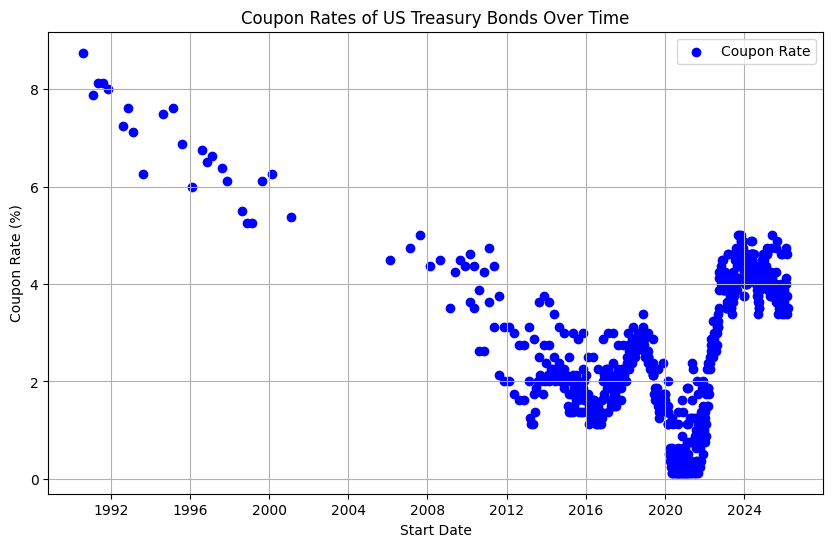

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(bond_symbology_df['start_date'], bond_symbology_df['coupon'], color='blue', label='Coupon Rate')
plt.xlabel('Start Date')
plt.ylabel('Coupon Rate (%)')
plt.title('Coupon Rates of US Treasury Bonds Over Time')
plt.legend()
plt.grid(True)
plt.show()

#### - The overall level of issued coupons released since 2024 has decreased over time and rose after 2020

## c. Load the on-the-run US treasuries

Load the `govt_on_the_run` Excel file into a dataframe. Select the current on-the-run 2Y, 3Y, 5Y, 7Y, 10Y, 20Y and 30Y issues (off-the-run issues have the B & C suffix). Create a separate symbology dataframe for on-the-run treasuries only, to be used later on for the on-the-run government yield curve bootstrapping.

In [31]:
govt_bonds_df = pd.read_excel('data/govt_on_the_run.xlsx')
pattern = r'GT[0-9]+ Govt'
mask = govt_bonds_df['ticker'].str.contains(pattern, regex=True)
govt_bonds_df = govt_bonds_df[mask]
govt_bonds_df.head()

,ticker,date,figi,isin
0,GT10 Govt,2026-03-23,BBG01ZZ4GDR9,US91282CPZ85
3,GT2 Govt,2026-03-23,BBG020BMV715,US91282CQB09
4,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33
9,GT3 Govt,2026-03-23,BBG020PVMGR2,US91282CQE48
10,GT30 Govt,2026-03-23,BBG01ZZ4GDS8,US912810UR76


## d. Compute the total amount of US Treasuries issued / matured every year since 2019

Column `amt_out` contains the issue amount outstanding, expressed in $MM.

Compute the total amount of US Treasuries issued every year since 2019.
Compute the total amount of US Treasuries matured every year since 2019.

Plot the results.

In [48]:
issued = bond_symbology_df.copy()
issued['issue_year'] = issued['start_date'].dt.year
issued['maturity'] = issued['maturity'].dt.year
issued.reset_index(inplace=True, drop=True)
issued.head()
total_issued = issued.groupby('issue_year')['amt_out'].sum()
total_matured = issued.groupby('maturity')['amt_out'].sum()
total_issued

issue_year
1990      17059.0
1991      60281.0
1992      17552.0
1993      38441.0
1994       9604.0
1995      20696.0
1996      32508.0
1997      40740.0
1998      22723.0
1999      22529.0
2000      17043.0
2001      16428.0
2006      26397.0
2007      38002.0
2008      48025.0
2009     150683.0
2010     309751.0
2011     442522.0
2012     506100.0
2013     605696.0
2014     859940.0
2015     988924.0
2016    1217460.0
2017    1330458.0
2018    1940847.0
2019    2322466.0
2020    3558513.0
2021    4601404.0
2022    3251806.0
2023    3028042.0
2024    4012135.0
2025    3817659.0
2026     638191.0
Name: amt_out, dtype: float64

In [49]:
total_matured

maturity
2020     609714.0
2021    2068029.0
2022    2249135.0
2023    2631092.0
2024    2629231.0
2025    2546043.0
2026    2922688.0
2027    3148505.0
2028    2622922.0
2029    1968116.0
2030    1770500.0
2031    1282647.0
2032    1078999.0
2033     556431.0
2034     476991.0
2035     383640.0
2036      80298.0
2037      38002.0
2038      48025.0
2039     150683.0
2040     396120.0
2041     497550.0
2042     364121.0
2043     338740.0
2044     314990.0
2045     279799.0
2046     183906.0
2047     169267.0
2048     198450.0
2049     236479.0
2050     308693.0
2051     366237.0
2052     297702.0
2053     266595.0
2054     275118.0
2055     223083.0
2056      32084.0
Name: amt_out, dtype: float64

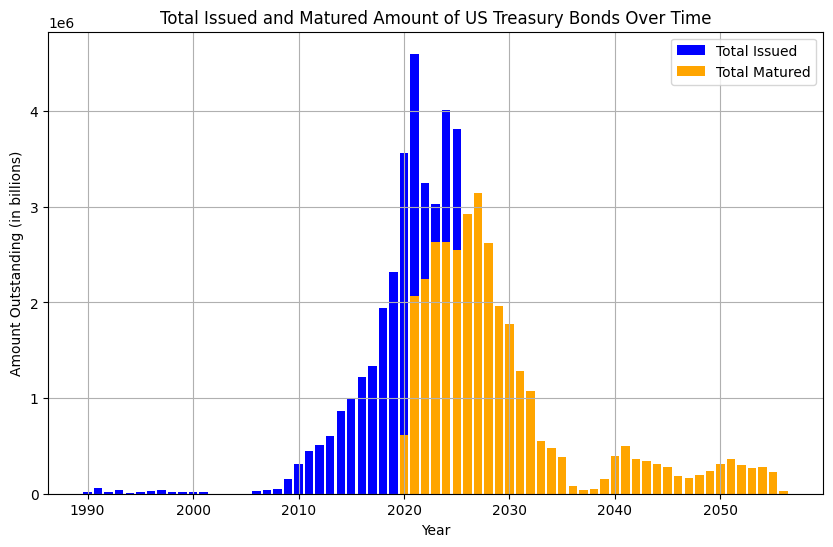

In [50]:
plt.figure(figsize=(10, 6))
plt.bar(total_issued.index, total_issued.values, color='blue', label='Total Issued')
plt.bar(total_matured.index, total_matured.values, color='orange', label='Total Matured')
plt.xlabel('Year')
plt.ylabel('Amount Outstanding (in billions)')
plt.title('Total Issued and Matured Amount of US Treasury Bonds Over Time')
plt.legend()
plt.grid(True)
plt.show()

------------------------------------------------------------------------------------------
# Problem 2: Explore symbology for corporate bonds

## a. Load and explore US corporate bonds symbology data

Starting from the `bond_symbology` dataframe, create a corporate bond dataframe containing
* corporate bond only  (class = "Corp"),
* senior unsecured (rank = "Sr Unsecured"),
* fixed coupon (cpn_type="FIXED")
* maturity date <= 2055-12-31

bonds only, with following columns:



| ticker | isin | figi | security | name | coupon | start_date | maturity | amt_out | term | TTM |
|----------|-------|-------|-------------|-----|----------|---------|---------|---------|---------|---------|

where 
* `term` refers to the initial term/time-to-maturity in years
* `TTM` refers to the current time-to-maturity in years

Display the dataframe.

## b. Explore aggregated issue amount outstanding by issuer

Compute the total issue (face) amount outstanding for each issuer and display the results.

## c. Display the bond details for APPLE INC (ticker AAPL)

Create a separate dataframe for Apple issuer only (ticker = 'AAPL') and display it.

Compute following aggregated metrics for AAPL:
* average coupon
* average term and
* average TTM.

## d. Explore term structure of issue amounts outstanding for Apple.

Plot the issue amount outstanding by TTM for Apple.

------------------------------------------------------------------------------------------
# Problem 3: Explore EOD market prices and yields

## a. Load and explore treasury market prices and yields

Load the `bond_market_prices_eod` Excel file into a dataframe. It provides market data for US treasuries and corporate bonds as of 2026-03-23.

Merge the treasuries symbology dataframe with the market data and add the following columns:


| date | bidPrice | askPrice | midPrice | bidYield | askYield | midYield | term | TTM |
|----------|-------|-------------|-----|----------|---------|---------|---------|---------|

Plot a graph/scatter plot of treasury mid yields by TTM.


## b. Explore on-the-run treasuries only
Create a separate joint dataframe for on-the-run treasuries only.

Plot a graph/scatter plot of on-the-run treasury mid yields by TTM.

## c. Load and explore corporate bond market prices and yields

Merge the filtered corporate bonds symbology dataframe with the market data and add the following columns:

| date | bidPrice | askPrice | midPrice | bidYield | askYield | midYield | term | TTM |
|----------|-------|-------------|-----|----------|---------|---------|---------|---------|

List the unique tickers/issuers available in the dataframe.


## d. Yield curve plots

Plot a graph/scatter plot of mid yield curves by TTM (one line per ticker/issuer).

Add a separate line for on-the-run US treasury yield curve (risk free curve).

What can you say about the credit issuer yields, compared to US treasury yields?

------------------------------------------------------------------------------------------
# Problem 4: Underying treasury benchmarks and credit spreads

## a. Add underlying benchmark bond mid yields

Start with the corporate bond symbology dataframe and filter following tickers only: AAPL, IBM, MSFT, ORCL and VZ. Use the column 'und_bench_yield' to identify the underlying benchmark bond for each bond issue.

Add two new columns to the joint corporate bond dataframe:

| und_bench_yield | credit_spread |
|----------|-------|

where 

*  `und_bench_yield` = underlying benchmark bond mid yield and
*  `credit_spread` = (issue yield - underlying benchmark bond mid yield) * 100.

## b. Credit spread curve plots

Plot a graph/scatter plot of credit spread curves by TTM (one line per issuer).


## c. Add g-spreads

Add two new columns to the joint corporate bond dataframe:

| interp_tsy_yield | g_spread |
|----------|-------|

where 

*  `interp_tsy_yield` = interpolated treasury yield (using on-the-run treasuries only), matching the issue maturity
*  `credit_spread` = (issue yield - underlying benchmark bond mid yield) * 100.

## d. G-spread curve plots

Plot a graph/scatter plot of g-spread curves by TTM (one line per issuer).
